In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from topo.base.ann import kNN
from topo.tpgraph.kernels import Kernel
from topo.spectral.eigen import EigenDecomposition, spectral_layout
from topo.layouts.projector import Projector
from topo.topograph import _KERNEL_CONFIGS

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# TUNABLE CONSTANTS — edit this cell and re-run all cells below
# ══════════════════════════════════════════════════════════════════════════════

# ── Data source ──────────────────────────────────────────────────────────────
# Set USE_CUSTOM_DATA = True and fill DATA_PATH / COLOR_PATH to load your own.
USE_CUSTOM_DATA = False
DATA_PATH = "../data/my_data.npy"  # (n_samples, n_features) array
COLOR_PATH = ""  # optional: (n_samples,) array for coloring
SCALE_DATA = True  # recommended for Euclidean/cKNN when features have different units

# Swiss-roll settings (ignored when USE_CUSTOM_DATA = True)
N_SAMPLES = 2000
NOISE = 0.5
RANDOM_STATE = 42

# ── kNN graph ────────────────────────────────────────────────────────────────
N_NEIGHBORS = 15
METRIC = "euclidean"  # any metric accepted by the backend
BACKEND = "hnswlib"  # "hnswlib" | "nmslib" | "sklearn"

# ── Kernel version ───────────────────────────────────────────────────────────
# Choose one of:
#   "bw_adaptive"                              — adaptive-bandwidth Gaussian (default)
#   "bw_adaptive_alpha_decaying"               — + alpha-decaying exponent
#   "bw_adaptive_nbr_expansion"                — + expanded neighbor search
#   "bw_adaptive_alpha_decaying_nbr_expansion" — both alpha-decaying + expansion
#   "fuzzy"                                    — UMAP-style fuzzy simplicial sets
#   "cknn"                                     — continuous k-nearest-neighbors
#   "gaussian"                                 — fixed-bandwidth Gaussian (set SIGMA)
KERNEL_VERSION = "fuzzy"
SIGMA = 1.0  # bandwidth for "gaussian" kernel version
ANISOTROPY = 1.0  # alpha for diffusion operator (0–1)

# ── Eigendecomposition / scaffold ────────────────────────────────────────────
N_COMPONENTS_DM = 64  # eigenvectors to compute
DM_METHOD = "DM"  # "DM" | "msDM" | "LE"
EIGENSOLVER = "arpack"  # "arpack" | "lobpcg" | "amg"
DIFFUSION_TIME = 10  # t=0 → multiscale; t>0 → fixed-time DM

# ── 2-D layout ───────────────────────────────────────────────────────────────
PROJECTION_METHOD = "PaCMAP"  # "MAP" | "UMAP" | "PaCMAP" | "Isomap" | "t-SNE"
N_COMPONENTS_2D = 2
NUM_ITERS = 500  # optimization iterations (MAP / UMAP)

In [41]:
# ── Load or generate data ─────────────────────────────────────────────────────
if USE_CUSTOM_DATA:
    X = np.load(Path(DATA_PATH))
    if COLOR_PATH:
        color = np.load(Path(COLOR_PATH))
    else:
        color = np.arange(X.shape[0])
    print(f"Loaded custom data: {X.shape}")
else:
    from sklearn.datasets import make_swiss_roll

    X, color = make_swiss_roll(
        n_samples=N_SAMPLES, noise=NOISE, random_state=RANDOM_STATE
    )
    print(f"Generated Swiss Roll: {X.shape}")

if SCALE_DATA:
    from sklearn.preprocessing import StandardScaler

    X = StandardScaler().fit_transform(X)
    print("Applied StandardScaler to X")

Loaded custom data: (4379, 10)
Applied StandardScaler to X


In [42]:
# ── Step 1: kNN graph in input space ──────────────────────────────────────────
knn_X = kNN(X, n_neighbors=N_NEIGHBORS, metric=METRIC, backend=BACKEND)

# ── Step 2: kernel on input space ─────────────────────────────────────────────
# Build Kernel kwargs from the chosen KERNEL_VERSION
kernel_cfg = _KERNEL_CONFIGS[KERNEL_VERSION].copy()
if KERNEL_VERSION == "gaussian":
    kernel_cfg["sigma"] = SIGMA

kernel_X = Kernel(
    n_neighbors=N_NEIGHBORS,
    metric=METRIC,
    backend=BACKEND,
    anisotropy=ANISOTROPY,
    **kernel_cfg,
)
kernel_X.fit(X)
P_X = kernel_X.P  # diffusion operator
L_X = kernel_X.L  # graph Laplacian

print(f"Kernel version : {KERNEL_VERSION}")
print(f"K shape        : {kernel_X.K.shape},  nnz = {kernel_X.K.nnz}")

# ── Step 3: eigendecomposition → scaffold ─────────────────────────────────────
eigen = EigenDecomposition(
    n_components=N_COMPONENTS_DM,
    method=DM_METHOD,
    eigensolver=EIGENSOLVER,
    drop_first=True,
    weight=True,
    t=DIFFUSION_TIME,
)
eigen.fit(kernel_X)
Z = eigen.transform(X)  # (n, n_eigs) scaffold coordinates

print(f"Scaffold method: {DM_METHOD},  shape = {Z.shape}")

Kernel version : fuzzy
K shape        : (4379, 4379),  nnz = 89492
Scaffold method: DM,  shape = (4379, 64)
Scaffold method: DM,  shape = (4379, 64)


In [43]:
# ── Step 4: kNN in scaffold space ─────────────────────────────────────────────
knn_Z = kNN(Z, n_neighbors=N_NEIGHBORS, metric=METRIC, backend=BACKEND)

# ── Step 5: refined kernel on scaffold ────────────────────────────────────────
kernel_Z = Kernel(
    n_neighbors=N_NEIGHBORS,
    metric=METRIC,
    backend=BACKEND,
    anisotropy=ANISOTROPY,
    **kernel_cfg,  # same kernel version as the base graph
)
kernel_Z.fit(Z)

# ── Step 6: spectral initialisation for layout ───────────────────────────────
init_Y = spectral_layout(
    graph=kernel_Z.K, dim=N_COMPONENTS_2D, random_state=RANDOM_STATE
)

# ── Step 7: 2-D layout ───────────────────────────────────────────────────────
proj = Projector(
    projection_method=PROJECTION_METHOD,
    n_components=N_COMPONENTS_2D,
    n_neighbors=N_NEIGHBORS,
    num_iters=NUM_ITERS,
    init="spectral",
)
# MAP consumes the kernel matrix; other methods take scaffold coordinates
if PROJECTION_METHOD == "MAP":
    proj.fit(kernel_Z.K)
else:
    proj.fit(Z)
Y = proj.Y_

print(f"Layout method  : {PROJECTION_METHOD},  shape = {Y.shape}")

Layout method  : PaCMAP,  shape = (4379, 2)


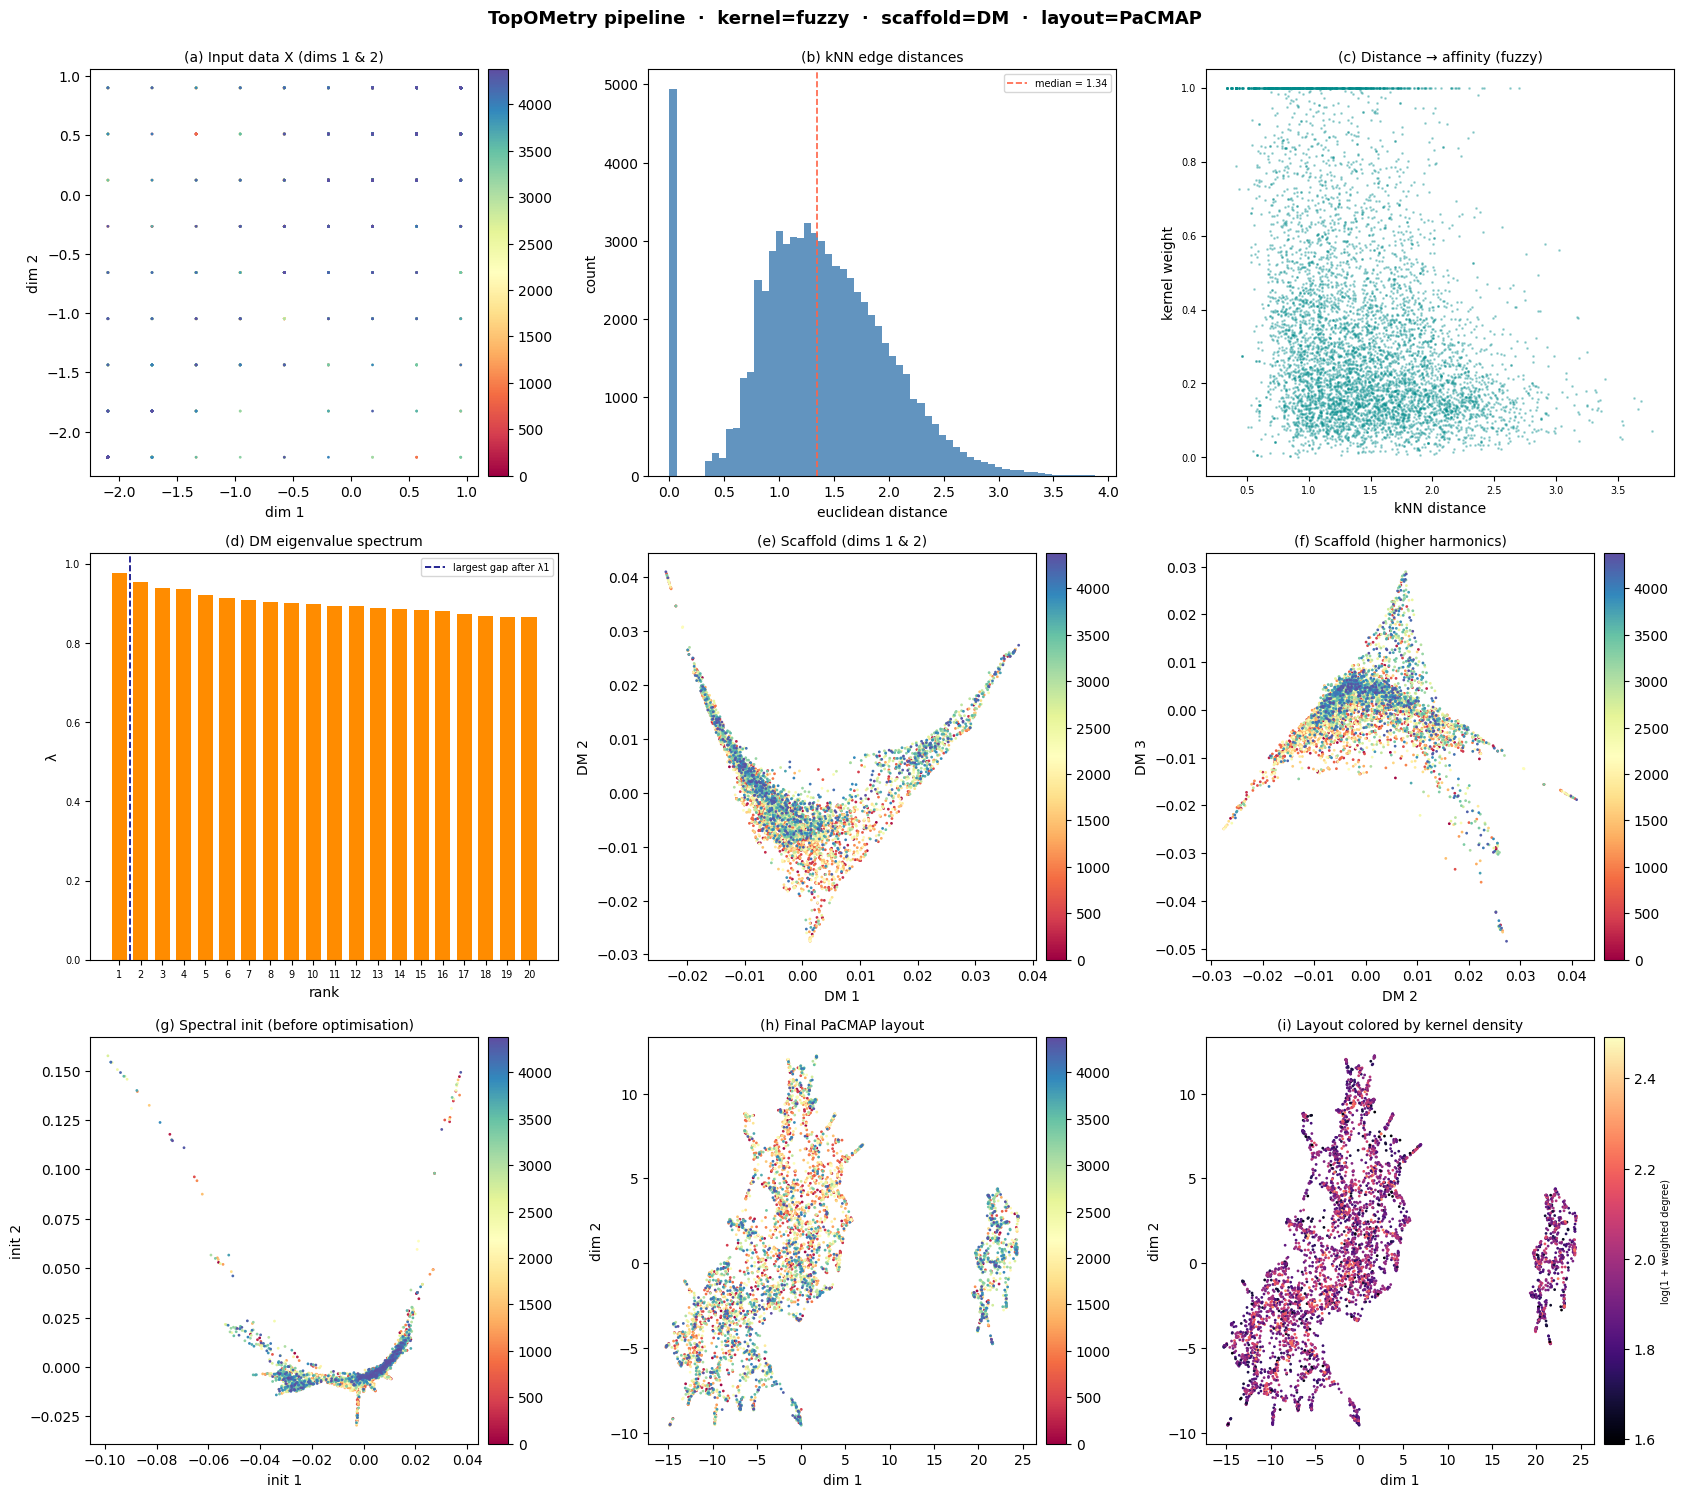

In [44]:
# ══════════════════════════════════════════════════════════════════════════════
# Visualization — 3×3 panel overview of the full pipeline
# ══════════════════════════════════════════════════════════════════════════════

n_dim = X.shape[1]
use_3d = n_dim >= 3 and not USE_CUSTOM_DATA

fig = plt.figure(figsize=(17, 15))
title = (
    f"TopOMetry pipeline  ·  kernel={KERNEL_VERSION}  ·  scaffold={DM_METHOD}  "
    f"·  layout={PROJECTION_METHOD}"
)
fig.suptitle(title, fontsize=13, fontweight="bold", y=0.995)

# ═══════════════════════════════════════════════════════════════════════════
# Row 1 — Input space: data → graph → kernel
# ═══════════════════════════════════════════════════════════════════════════

# ── 1  Input data ────────────────────────────────────────────────────────
if use_3d:
    ax1 = fig.add_subplot(3, 3, 1, projection="3d")
    ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, cmap="Spectral", s=4, linewidths=0)
    ax1.set_title("(a) Input data X", fontsize=10)
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.set_zlabel("z")
    ax1.tick_params(labelsize=6)
else:
    ax1 = fig.add_subplot(3, 3, 1)
    sc1 = ax1.scatter(X[:, 0], X[:, 1], c=color, cmap="Spectral", s=4, linewidths=0)
    ax1.set_title("(a) Input data X (dims 1 & 2)", fontsize=10)
    ax1.set_xlabel("dim 1")
    ax1.set_ylabel("dim 2")
    plt.colorbar(sc1, ax=ax1, pad=0.02)

# ── 2  kNN edge-distance distribution ───────────────────────────────────
ax2 = fig.add_subplot(3, 3, 2)
edge_dists = knn_X.data
ax2.hist(edge_dists, bins=60, color="steelblue", edgecolor="none", alpha=0.85)
med = np.median(edge_dists)
ax2.axvline(med, color="tomato", lw=1.2, ls="--", label=f"median = {med:.2f}")
ax2.set_title("(b) kNN edge distances", fontsize=10)
ax2.set_xlabel(f"{METRIC} distance")
ax2.set_ylabel("count")
ax2.legend(fontsize=7)

# ── 3  Distance → kernel affinity ───────────────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
K_csr = kernel_X.K.tocsr()
knn_csr = knn_X.tocsr()
rows, cols = K_csr.nonzero()
if len(rows) > 10_000:
    rng = np.random.default_rng(RANDOM_STATE)
    sel = rng.choice(len(rows), 10_000, replace=False)
    rows, cols = rows[sel], cols[sel]
d_vals = np.asarray(knn_csr[rows, cols]).ravel()
k_vals = np.asarray(K_csr[rows, cols]).ravel()
mask = d_vals > 0
ax3.scatter(
    d_vals[mask], k_vals[mask], s=1, alpha=0.3, color="darkcyan", rasterized=True
)
ax3.set_title(f"(c) Distance → affinity ({KERNEL_VERSION})", fontsize=10)
ax3.set_xlabel("kNN distance")
ax3.set_ylabel("kernel weight")
ax3.tick_params(labelsize=7)

# ═══════════════════════════════════════════════════════════════════════════
# Row 2 — Spectral scaffold
# ═══════════════════════════════════════════════════════════════════════════

# ── 4  Eigenvalue spectrum ──────────────────────────────────────────────
ax4 = fig.add_subplot(3, 3, 4)
evals = eigen.eigenvalues
n_show = min(20, len(evals))
idx = np.arange(1, n_show + 1)
ax4.bar(idx, evals[:n_show], color="darkorange", width=0.7)
gaps = np.abs(np.diff(evals[:n_show]))
gap_idx = np.argmax(gaps)
ax4.axvline(
    gap_idx + 1.5,
    color="navy",
    lw=1.2,
    ls="--",
    label=f"largest gap after λ{gap_idx + 1}",
)
ax4.set_title(f"(d) {DM_METHOD} eigenvalue spectrum", fontsize=10)
ax4.set_xlabel("rank")
ax4.set_ylabel("λ")
ax4.set_xticks(idx)
ax4.tick_params(labelsize=7)
ax4.legend(fontsize=7)

# ── 5  Scaffold dims 1 & 2 ──────────────────────────────────────────────
ax5 = fig.add_subplot(3, 3, 5)
sc5 = ax5.scatter(Z[:, 0], Z[:, 1], c=color, cmap="Spectral", s=4, linewidths=0)
ax5.set_title("(e) Scaffold (dims 1 & 2)", fontsize=10)
ax5.set_xlabel(f"{DM_METHOD} 1")
ax5.set_ylabel(f"{DM_METHOD} 2")
plt.colorbar(sc5, ax=ax5, pad=0.02)

# ── 6  Scaffold dims 2 & 3 (higher harmonics) ──────────────────────────
ax6 = fig.add_subplot(3, 3, 6)
if Z.shape[1] >= 3:
    sc6 = ax6.scatter(Z[:, 1], Z[:, 2], c=color, cmap="Spectral", s=4, linewidths=0)
    ax6.set_xlabel(f"{DM_METHOD} 2")
    ax6.set_ylabel(f"{DM_METHOD} 3")
else:
    sc6 = ax6.scatter(Z[:, 0], Z[:, 1], c=color, cmap="Spectral", s=4, linewidths=0)
    ax6.set_xlabel(f"{DM_METHOD} 1")
    ax6.set_ylabel(f"{DM_METHOD} 2")
ax6.set_title("(f) Scaffold (higher harmonics)", fontsize=10)
plt.colorbar(sc6, ax=ax6, pad=0.02)

# ═══════════════════════════════════════════════════════════════════════════
# Row 3 — Layout
# ═══════════════════════════════════════════════════════════════════════════

# ── 7  Spectral initialisation ──────────────────────────────────────────
ax7 = fig.add_subplot(3, 3, 7)
sc7 = ax7.scatter(
    init_Y[:, 0], init_Y[:, 1], c=color, cmap="Spectral", s=4, linewidths=0
)
ax7.set_title("(g) Spectral init (before optimisation)", fontsize=10)
ax7.set_xlabel("init 1")
ax7.set_ylabel("init 2")
plt.colorbar(sc7, ax=ax7, pad=0.02)

# ── 8  Final 2-D layout ────────────────────────────────────────────────
ax8 = fig.add_subplot(3, 3, 8)
sc8 = ax8.scatter(Y[:, 0], Y[:, 1], c=color, cmap="Spectral", s=4, linewidths=0)
ax8.set_title(f"(h) Final {PROJECTION_METHOD} layout", fontsize=10)
ax8.set_xlabel("dim 1")
ax8.set_ylabel("dim 2")
plt.colorbar(sc8, ax=ax8, pad=0.02)

# ── 9  Local density on layout ──────────────────────────────────────────
# Weighted degree = row sums of the kernel matrix (∝ local density)
ax9 = fig.add_subplot(3, 3, 9)
log_degree = np.log1p(np.asarray(kernel_Z.K.sum(axis=1)).ravel())
sc9 = ax9.scatter(Y[:, 0], Y[:, 1], c=log_degree, cmap="magma", s=4, linewidths=0)
ax9.set_title("(i) Layout colored by kernel density", fontsize=10)
ax9.set_xlabel("dim 1")
ax9.set_ylabel("dim 2")
cb = plt.colorbar(sc9, ax=ax9, pad=0.02)
cb.set_label("log(1 + weighted degree)", fontsize=7)

plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Quick reference — all available options
# ══════════════════════════════════════════════════════════════════════════════
print("""
┌─────────────────────────────────────────────────────────────────────┐
│  KERNEL_VERSION options:                                            │
│    "bw_adaptive"                 — adaptive-bandwidth Gaussian      │
│    "bw_adaptive_alpha_decaying"  — + alpha-decaying exponent        │
│    "bw_adaptive_nbr_expansion"   — + expanded neighbor search       │
│    "bw_adaptive_alpha_decaying_nbr_expansion" — both combined       │
│    "fuzzy"                       — UMAP-style fuzzy simplicial sets │
│    "cknn"                        — continuous k-nearest-neighbors   │
│    "gaussian"                    — fixed-bandwidth (set SIGMA)      │
├─────────────────────────────────────────────────────────────────────┤
│  DM_METHOD options:                                                 │
│    "DM"    — diffusion maps                                         │
│    "msDM"  — multiscale diffusion maps                              │
│    "LE"    — Laplacian eigenmaps                                    │
├─────────────────────────────────────────────────────────────────────┤
│  PROJECTION_METHOD options:                                         │
│    "MAP"     — Manifold Approximation and Projection (native)       │
│    "UMAP"    — Uniform Manifold Approximation (pip install umap)    │
│    "PaCMAP"  — Pairwise Controlled Manifold Approx.                 │
│    "Isomap"  — Isometric Mapping                                    │
│    "t-SNE"   — t-distributed Stochastic Neighbor Embedding          │
│    "TriMAP"  — TriMap (pip install trimap)                           │
│    "NCVis"   — NCVis (pip install ncvis)                             │
│    "IsomorphicMDE" — MDE isomorphic (pip install pymde)             │
│    "IsometricMDE"  — MDE isometric (pip install pymde)              │
├─────────────────────────────────────────────────────────────────────┤
│  METRIC options (depends on backend):                               │
│    "euclidean", "cosine", "l1", "angular", "hamming", ...           │
├─────────────────────────────────────────────────────────────────────┤
│  BACKEND options:                                                   │
│    "hnswlib" (default, fast)  |  "nmslib"  |  "sklearn" (exact)     │
└─────────────────────────────────────────────────────────────────────┘

To load your own data, set USE_CUSTOM_DATA = True in cell 2 and point
DATA_PATH to a .npy file of shape (n_samples, n_features).
Optionally set COLOR_PATH to a .npy file of shape (n_samples,).
""")